# Train Seq to Seq

In [2]:
import torch
from torch import nn
import pandas as pd

In [3]:
df_train = pd.read_csv('field_f2')
df_train.drop('datetime', axis=1, inplace=True)
print(df_train.shape)
print(df_train.columns)
#df_train.set_index('datetime', inplace=True)

df_test = pd.read_csv('field_f4')
df_test.drop('datetime', axis=1, inplace=True)
print(df_test.shape)
print(df_test.columns)
#df_test.set_index('datetime', inplace=True)

(3698, 14)
Index(['s_a', 's_b', 'irr', 'temperature_2m', 'relative_humidity_2m',
       'cloud_cover', 'wind_speed_10m', 'wind_direction_100m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'rain', 'precipitation',
       'evapotranspiration'],
      dtype='object')
(3698, 14)
Index(['s_a', 's_b', 'irr', 'temperature_2m', 'relative_humidity_2m',
       'cloud_cover', 'wind_speed_10m', 'wind_direction_100m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'rain', 'precipitation',
       'evapotranspiration'],
      dtype='object')


In [4]:
import torch
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_window, output_window):
        """
        Args:
            data (torch.Tensor or np.array): time series data, shape (time_steps, features) or (time_steps,)
            input_window (int): number of time steps for input
            output_window (int): number of time steps to predict
        """
        if isinstance(data, np.ndarray):
            data = torch.tensor(data, dtype=torch.float32)

        self.data = data
        self.input_window = input_window
        self.output_window = output_window
        self.length = len(data) - input_window - output_window + 1

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_window]
        y = self.data[idx + self.input_window : idx + self.input_window + self.output_window, 0:2]
        
        
        return x, y

In [5]:
import numpy as np
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

# Dummy time series data
#time_series = np.sin(np.linspace(0, 100, 500))  # shape: (500,)
time_series_train = df_train.to_numpy()
time_series_test = df_test.to_numpy()

scaler = StandardScaler()
scaler.fit(time_series_train)
time_series_train = scaler.transform(time_series_train.astype(float))
time_series_test = scaler.transform(time_series_test.astype(float))
#time_series_train = StandardScaler().fit(time_series_train).transform(time_series_train.astype(float))



input_window = 30
output_window = 12

dataset_train = TimeSeriesDataset(time_series_train, input_window, output_window)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

dataset_test = TimeSeriesDataset(time_series_test, input_window, output_window)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)

# Fetch one batch
for x_batch, y_batch in dataloader_train:
    print("Input batch shape:", x_batch.shape)   # (batch_size, input_window, features_in)
    print("Target batch shape:", y_batch.shape)  # (batch_size, output_window, features_target)
    break

Input batch shape: torch.Size([32, 30, 14])
Target batch shape: torch.Size([32, 12, 2])


In [6]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)

    def forward(self, x):
        # x: (batch_size, input_seq_len, input_size)
        outputs, hidden = self.rnn(x)  # hidden: (1, batch, hidden_size)
        return hidden


class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size):
        super(Decoder, self).__init__()
        self.rnn = nn.RNN(input_size=output_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, decoder_input, hidden):
        # decoder_input: (batch_size, 1, output_size) ← one timestep
        output, hidden = self.rnn(decoder_input, hidden)
        output = self.fc(output)  # (batch_size, 1, output_size)
        return output, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, output_seq_len):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.output_seq_len = output_seq_len

    def forward(self, x):
        batch_size = x.size(0)
        output_size = self.decoder.fc.out_features
        
        hidden = self.encoder(x)

        # Start with zeros or a special <START> token
        decoder_input = torch.zeros(batch_size, 1, output_size, device=x.device)

        outputs = []

        for _ in range(self.output_seq_len):
            output, hidden = self.decoder(decoder_input, hidden)
            outputs.append(output)
            decoder_input = output  # Teacher forcing could go here

        return torch.cat(outputs, dim=1)

torch.Size([32, 12, 2])


  0%|          | 0/60 [00:00<?, ?it/s]/Users/beppe2hd/miniforge3/envs/PureCircle/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([32, 12, 1])) that is different to the input size (torch.Size([32, 12, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/beppe2hd/miniforge3/envs/PureCircle/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([9, 12, 1])) that is different to the input size (torch.Size([9, 12, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 60/60 [00:27<00:00,  2.16it/s]


[0.97089328 0.95426024 0.92253899 0.50143637 0.23412055 0.18600414
 0.16350498 0.15222713 0.14442621 0.13973171 0.13520481 0.12857804
 0.12621325 0.12374055 0.12327157 0.12042424 0.11985814 0.11904128
 0.11651945 0.11549453 0.11434561 0.11181852 0.11167736 0.10812315
 0.10587721 0.10070733 0.0867994  0.07181229 0.06402425 0.05997867
 0.05417559 0.04932509 0.04567736 0.04391524 0.04068157 0.03940964
 0.03871664 0.03714539 0.03727562 0.03569072 0.03483145 0.03465213
 0.03416346 0.03397325 0.03477591 0.03303889 0.03234007 0.03246398
 0.03335956 0.03185588 0.0324142  0.0323808  0.03150832 0.03077486
 0.0309977  0.03031841 0.02955979 0.03188775 0.03084405 0.0307144 ]


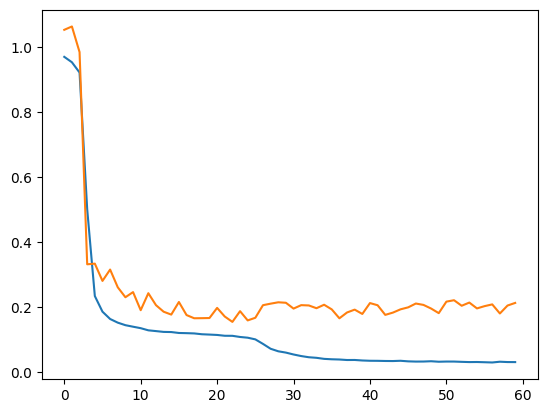

In [7]:
from tqdm import tqdm
from matplotlib import pyplot as plt


# Example
batch_size = 32

input_size = 14
hidden_size = 20
output_size = 2

input_seq_len = 30
output_seq_len = 12
epochs = 60

encoder = Encoder(input_size, hidden_size)
decoder = Decoder(output_size, hidden_size)
model = Seq2Seq(encoder, decoder, output_seq_len)

x = torch.randn(32, input_seq_len, input_size)
y = model(x)
print(y.shape)  

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.MSELoss()
train_losses = np.zeros(epochs)
test_losses = np.zeros(epochs)

for epoch in tqdm(range(epochs)):
    model.train()
    train_loss = 0.
    count = 0
    for x_batch, y_batch in dataloader_train:
        count += 1
        x_batch = x_batch.type(torch.float32)
        y_batch = y_batch.type(torch.float32)
        # Forward pass
        outputs = model(x_batch)

        loss = criterion(outputs, y_batch)
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_losses[epoch] = train_loss / count

    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_loss = 0.
        count = 0
        for x_batch, y_batch in dataloader_test:
            count += 1
            x_batch = x_batch.type(torch.float32)
            y_batch = y_batch.type(torch.float32)
            # Forward pass
            outputs = model(x_batch)

            loss = criterion(outputs, torch.unsqueeze(y_batch[:, :, -1], axis=2))
            test_loss += loss.item()
        
        test_losses[epoch] = test_loss / count

print(train_losses)
plt.plot(train_losses)
plt.plot(test_losses)